In [1]:
# ==========================================
# 0. Setup & Imports
# ==========================================
!pip install shap lime umap-learn wordcloud

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.kernel_approximation import Nystroem
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score
from sklearn.model_selection import train_test_split

# Visualization & xAI
import umap.umap_ as umap
import shap
import lime
import lime.lime_tabular
from lime.lime_text import LimeTextExplainer
from tqdm.auto import tqdm

# Configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 33.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.8.0 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.8.0 which is incompatible.


2025-12-10 09:21:25.595234: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765358485.746199      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765358485.786934      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
# ==========================================
# 1. Data Loading
# ==========================================
class Config:
    POS_DATA_FILE = "/kaggle/input/lrec-tcs-attack-support/sentencePair.txt"
    NEG_DATA_FILE = "/kaggle/input/lrec-tcs-attack-support/sentencePair_neg.txt"
    EMB_PATH = "/kaggle/input/lrec-tcs-attack-vs-support-finetuned-embeddings/lbert_finetuned_embeddings.npy"

def parse_lrec_line(line: str):
    parts = line.strip().split("\t")
    fname_indices = [i for i, p in enumerate(parts) if p.endswith(".txt")]
    if len(fname_indices) != 2: return None
    try:
        sentpair_id = int(parts[0]) 
        sent1 = " ".join(parts[fname_indices[0] + 2 : fname_indices[1]]).strip('"')
        sent2 = " ".join(parts[fname_indices[1] + 2 : len(parts) - 2]).strip('"')
        label = parts[-1]
    except: return None
    return {"sentpair_id": sentpair_id, "sent1": sent1, "sent2": sent2, "label": label}

def load_data(config):
    rows = []
    for fp in [config.POS_DATA_FILE, config.NEG_DATA_FILE]:
        if os.path.exists(fp):
            with open(fp, "r", encoding="utf-8") as f:
                for line in f:
                    if p := parse_lrec_line(line):
                        if 'id' in p: p['sentpair_id'] = p.pop('id')
                        rows.append(p)
    df = pd.DataFrame(rows)
    LABEL_MAP = {"SUPPORT": 0, "ATTACK": 1, "NO_REL": 2}
    df["label_id"] = df["label"].map(LABEL_MAP)
    df = df.dropna(subset=["sentpair_id", "sent1", "sent2", "label_id"])
    
    # Stratified Split to match embedding order
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label_id"])
    return pd.concat([train_df, test_df]).reset_index(drop=True)

print("Loading Data...")
df = load_data(Config())
embeddings = np.load(Config.EMB_PATH)
print(f"Loaded: DF {df.shape}, Emb {embeddings.shape}")

# Create text column for analysis
df['text_combined'] = df['sent1'] + " [SEP] " + df['sent2']

Loading Data...
Loaded: DF (40506, 5), Emb (40506, 768)



 PART 1: Supervised SVM Classification
Training Supervised SVM (RBF)...

--- Supervised SVM Report ---
              precision    recall  f1-score   support

     SUPPORT       0.84      0.84      0.84      2150
      ATTACK       0.82      0.82      0.82      1952
      NO_REL       0.93      0.93      0.93      4000

    accuracy                           0.88      8102
   macro avg       0.86      0.86      0.86      8102
weighted avg       0.88      0.88      0.88      8102



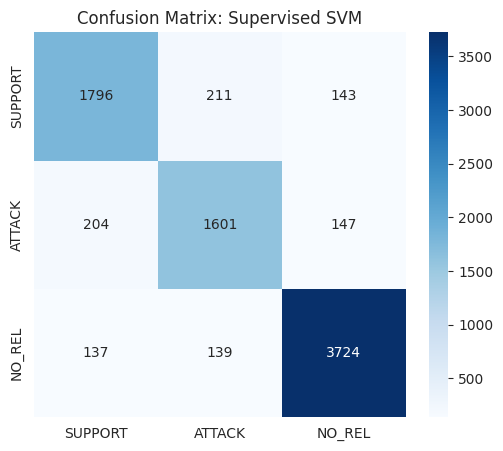


 PART 2: Unsupervised SVM Clustering
Projecting data to Kernel Space...
Analyzing Optimal Clusters...


  0%|          | 0/6 [00:00<?, ?it/s]

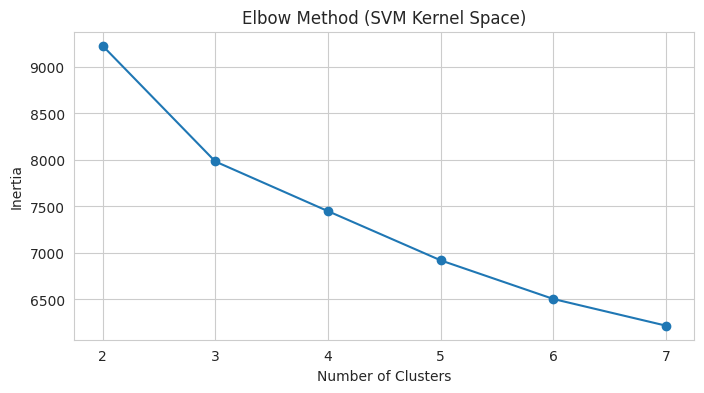

Fitting Final SVM-Clusters (k=3)...

Cluster Interpretation:
  Cluster 0 -> Dominant Label: ATTACK
  Cluster 1 -> Dominant Label: NO_REL
  Cluster 2 -> Dominant Label: SUPPORT


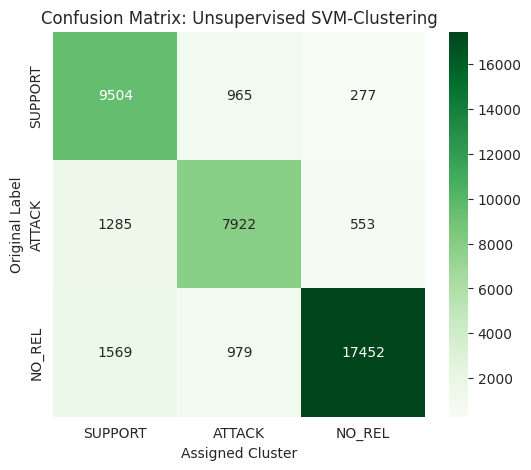


 PART 3: Visualization
Generating UMAP...


n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


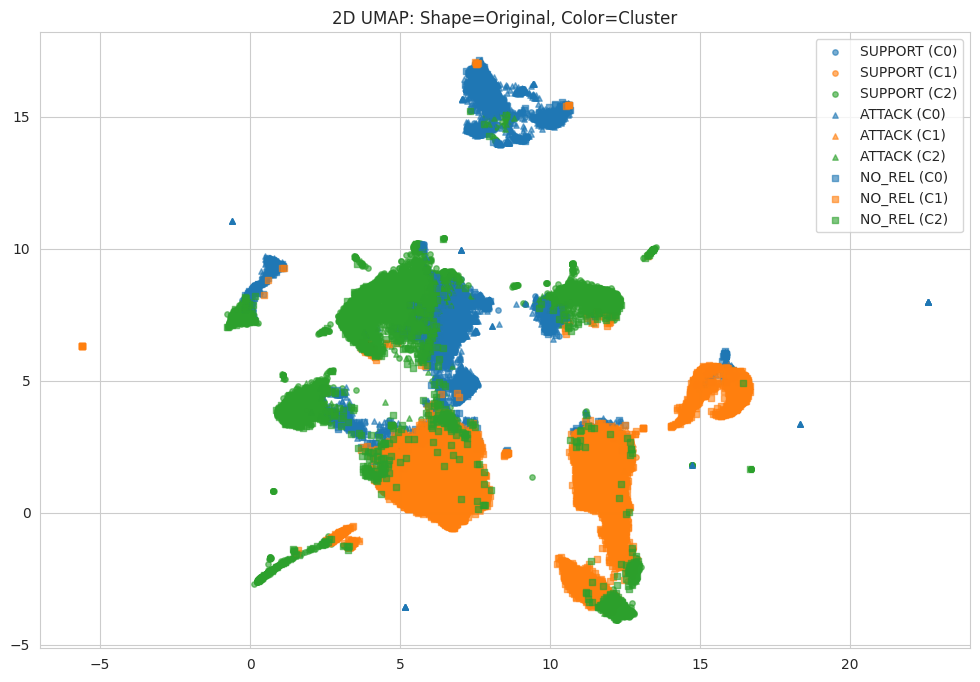

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


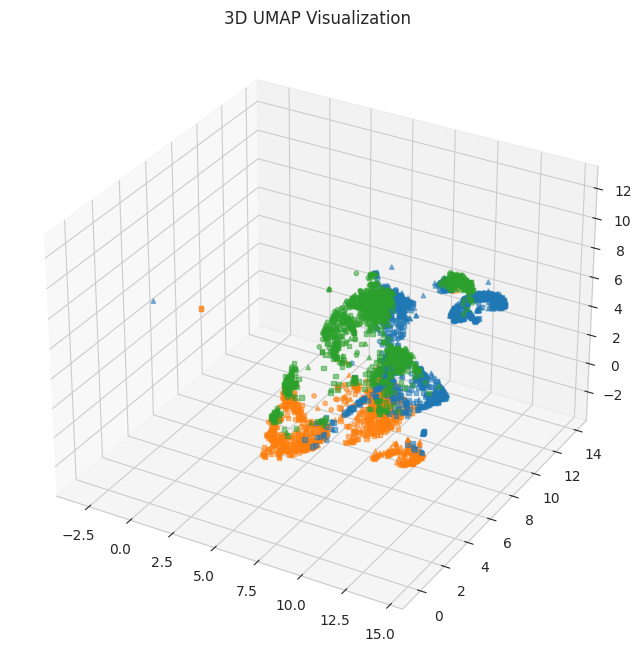

In [3]:
# ==========================================
# PART 2: Supervised SVM
# ==========================================
print("\n" + "="*40 + "\n PART 1: Supervised SVM Classification\n" + "="*40)

X = embeddings
y = df['label_id'].values
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training Supervised SVM (RBF)...")
# Using probability=True for xAI later. Cache size increased for speed.
svm_sup = SVC(kernel='rbf', C=1.0, probability=True, random_state=42, cache_size=2000)
svm_sup.fit(X_train, y_train)

y_pred = svm_sup.predict(X_val)
target_names = ["SUPPORT", "ATTACK", "NO_REL"]

print("\n--- Supervised SVM Report ---")
print(classification_report(y_val, y_pred, target_names=target_names))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix: Supervised SVM")
plt.show()

# ==========================================
# PART 2: Unsupervised SVM Clustering
# ==========================================
print("\n" + "="*40 + "\n PART 2: Unsupervised SVM Clustering\n" + "="*40)

# Project to SVM Kernel Space (Nystroem approximation for scalability)
print("Projecting data to Kernel Space...")
feature_map = Nystroem(gamma=None, random_state=42, n_components=300) 
X_kernel = feature_map.fit_transform(embeddings)

# A. Optimal Clusters (Elbow Method)
print("Analyzing Optimal Clusters...")
sse = []
k_range = range(2, 8) 
sample_idx = np.random.choice(len(X_kernel), 5000, replace=False) # Sample for Silhouette

for k in tqdm(k_range):
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    km.fit(X_kernel)
    sse.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, sse, marker='o')
plt.title("Elbow Method (SVM Kernel Space)")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# B. Force 3 Clusters
print("Fitting Final SVM-Clusters (k=3)...")
svm_cluster_model = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = svm_cluster_model.fit_predict(X_kernel)
df['assigned_cluster'] = cluster_labels

# C. Map Clusters to Labels
cluster_map_name = {}
print("\nCluster Interpretation:")
for c in range(3):
    mask = df['assigned_cluster'] == c
    dom_label = df[mask]['label'].mode()[0]
    cluster_map_name[c] = dom_label
    print(f"  Cluster {c} -> Dominant Label: {dom_label}")

df['assigned_label_str'] = df['assigned_cluster'].map(cluster_map_name)

# D. Confusion Matrix (Unsupervised)
cm_unsup = confusion_matrix(df['label'], df['assigned_label_str'], labels=target_names)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_unsup, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix: Unsupervised SVM-Clustering")
plt.ylabel('Original Label')
plt.xlabel('Assigned Cluster')
plt.show()

# ==========================================
# PART 3: Visualization (UMAP)
# ==========================================
print("\n" + "="*40 + "\n PART 3: Visualization\n" + "="*40)

print("Generating UMAP...")
umap_2d = umap.UMAP(n_components=2, random_state=42).fit_transform(embeddings)

markers = {"ATTACK": "^", "SUPPORT": "o", "NO_REL": "s"}
colors = {0: "#1f77b4", 1: "#ff7f0e", 2: "#2ca02c"}

# 2D Plot
plt.figure(figsize=(12, 8))
for orig_lbl in target_names:
    for clust_id in range(3):
        mask = (df['label'] == orig_lbl) & (df['assigned_cluster'] == clust_id)
        if mask.sum() == 0: continue
        plt.scatter(
            umap_2d[mask, 0], umap_2d[mask, 1],
            c=[colors[clust_id]], marker=markers[orig_lbl],
            label=f"{orig_lbl} (C{clust_id})", s=15, alpha=0.6
        )
plt.title("2D UMAP: Shape=Original, Color=Cluster")
plt.legend()
plt.show()

# 3D Plot
umap_3d = umap.UMAP(n_components=3, random_state=42).fit_transform(embeddings)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for orig_lbl in target_names:
    for clust_id in range(3):
        mask = (df['label'] == orig_lbl) & (df['assigned_cluster'] == clust_id)
        if mask.sum() > 500: # Downsample for 3D performance
             mask_idxs = np.random.choice(np.where(mask)[0], 500, replace=False)
             sub = umap_3d[mask_idxs]
        else:
             sub = umap_3d[mask]
        
        ax.scatter(sub[:,0], sub[:,1], sub[:,2], c=[colors[clust_id]], marker=markers[orig_lbl], s=10, alpha=0.5)
ax.set_title("3D UMAP Visualization")
plt.show()


 PART 4: Cluster Interpretation (xAI)
Training Surrogate Text Model (TF-IDF + LogReg)...

--- Surrogate Model Performance ---
How well does the text model mimic the SVM clusters?


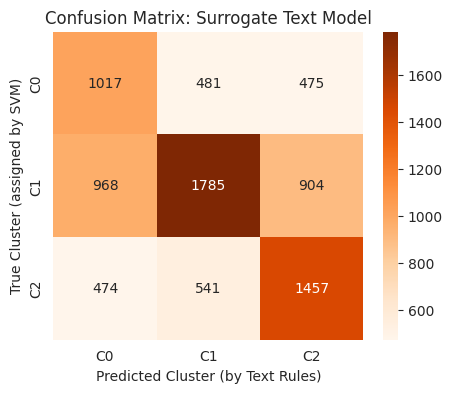

Note: High accuracy here means LIME explanations are TRUSTWORTHY.
If accuracy is low, the text explanations might not fully capture the embedding logic.

Generating LIME explanations for 100 random samples...


  0%|          | 0/100 [00:00<?, ?it/s]


Saved 100 LIME explanations to: lime_text_explanations_100.csv
       sentpair_id                                              sent1  \
18217         8713   Besides when a person is in jail custody and ...   
36418        17784  It is somewhat interesting that though the con...   
21123          430  The writ petition in the High Court itself cam...   

                                                   sent2    label  \
18217  No doubt , this decision does suggest that the...  SUPPORT   
36418  Clause ( a ) shows that where a petitioner is ...   NO_REL   
21123  Ordinarily , therefore , the power of the High...   NO_REL   

      assigned_label_str  assigned_cluster  \
18217            SUPPORT                 2   
36418             NO_REL                 1   
21123             NO_REL                 1   

                                        LIME_explanation  
18217  person (0.153); view (-0.148); concerned (0.13...  
36418  SEP (0.214); Properzi (-0.064); Rods (-0.053);...  
2112

In [4]:
# ==========================================
# PART 4: Cluster Interpretation (LIME Text & SHAP)
# ==========================================
print("\n" + "="*40 + "\n PART 4: Cluster Interpretation (xAI)\n" + "="*40)

# ---------------------------------------------------------
# A. Train Surrogate Text Model (TF-IDF + LogReg)
# ---------------------------------------------------------
print("Training Surrogate Text Model (TF-IDF + LogReg)...")

# 1. Create Pipeline (Use N-Grams for better phrases)
text_pipeline = make_pipeline(
    TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words='english'),
    LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
)

# 2. Train on the text to predict the ASSIGNED CLUSTER (not original label)
# We want to explain "Why did the SVM cluster it this way?"
X_text = df['text_combined']
y_cluster = df['assigned_cluster']

# Split to evaluate surrogate quality
X_txt_train, X_txt_val, y_txt_train, y_txt_val = train_test_split(
    X_text, y_cluster, test_size=0.2, random_state=42, stratify=y_cluster
)

text_pipeline.fit(X_txt_train, y_txt_train)

# ---------------------------------------------------------
# B. Surrogate Confusion Matrix
# ---------------------------------------------------------
print("\n--- Surrogate Model Performance ---")
print("How well does the text model mimic the SVM clusters?")
y_txt_pred = text_pipeline.predict(X_txt_val)

# Confusion Matrix
cm_surrogate = confusion_matrix(y_txt_val, y_txt_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_surrogate, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=["C0", "C1", "C2"], yticklabels=["C0", "C1", "C2"])
plt.title("Confusion Matrix: Surrogate Text Model")
plt.xlabel("Predicted Cluster (by Text Rules)")
plt.ylabel("True Cluster (assigned by SVM)")
plt.show()

print("Note: High accuracy here means LIME explanations are TRUSTWORTHY.")
print("If accuracy is low, the text explanations might not fully capture the embedding logic.")

# ---------------------------------------------------------
# C. Generate LIME Explanations for 100 Samples
# ---------------------------------------------------------
print("\nGenerating LIME explanations for 100 random samples...")
explainer_text = LimeTextExplainer(class_names=["Cluster 0", "Cluster 1", "Cluster 2"], random_state=42)

# Sample 100 points
sample_df = df.sample(100, random_state=42).copy()
lime_results = []

for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    text_content = row['text_combined']
    true_cluster = row['assigned_cluster']
    
    # Run LIME
    # We ask LIME to explain the probability of the *Predicted Cluster*
    # (labels parameter expects an iterable, usually we just want the top label)
    exp = explainer_text.explain_instance(
        text_content, 
        text_pipeline.predict_proba, 
        num_features=10, 
        labels=[true_cluster] # Only explain the class it actually belongs to
    )
    
    # Extract list of (word, weight)
    explanation_list = exp.as_list(label=true_cluster)
    
    # Format as string: "word1 (0.15), word2 (0.05), ..."
    # Sorted by absolute weight magnitude (relevance)
    explanation_list.sort(key=lambda x: abs(x[1]), reverse=True)
    explanation_str = "; ".join([f"{word} ({weight:.3f})" for word, weight in explanation_list])
    
    lime_results.append(explanation_str)

# Add to dataframe
sample_df['LIME_explanation'] = lime_results

# ---------------------------------------------------------
# D. Save Results
# ---------------------------------------------------------
output_cols = [
    "sentpair_id", "sent1", "sent2", "label", 
    "assigned_label_str", "assigned_cluster", "LIME_explanation"
]

save_path = "lime_text_explanations_100.csv"
sample_df[output_cols].to_csv(save_path, index=False)
print(f"\nSaved 100 LIME explanations to: {save_path}")

# Display first few rows
print(sample_df[output_cols].head(3))


2. SHAP (Embedding Feature Importance)...
Generating SHAP Summary Plot...


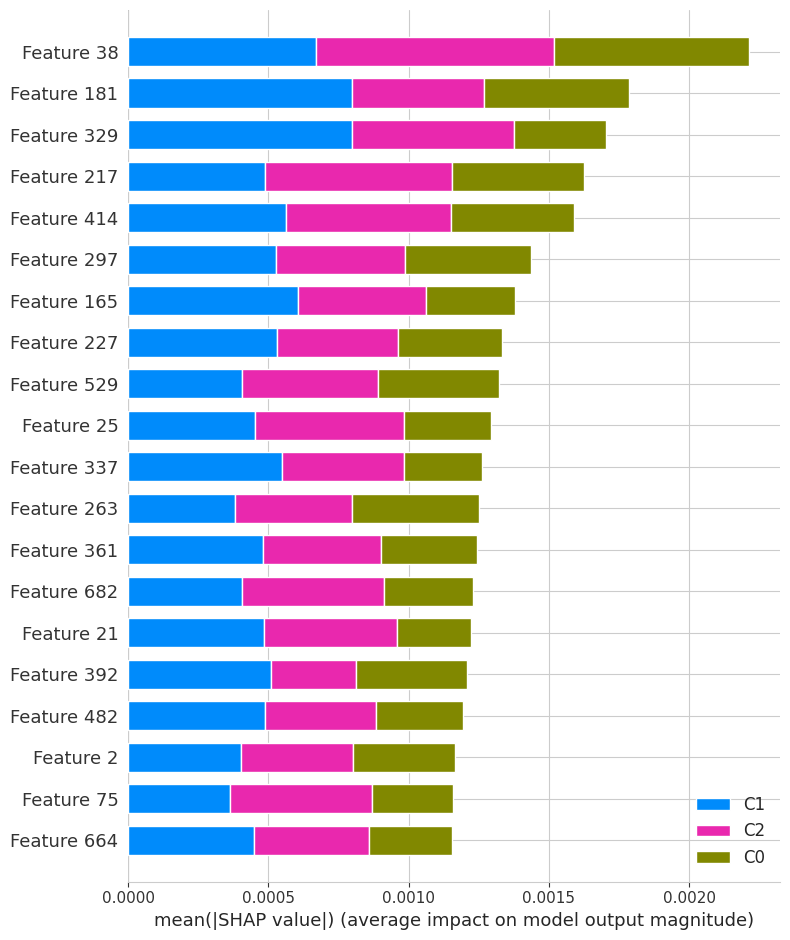


3. LIME (Tabular Embedding Analysis)...
Top Embedding Dimensions for Instance 0:
[('dim_604 <= -0.15', -0.002151705984422444), ('-2.06 < dim_308 <= -1.24', 0.0018206338470366204), ('dim_666 > 0.41', 0.0017975293113910741), ('-0.57 < dim_13 <= -0.16', 0.0017066199992273026), ('dim_537 > 0.60', -0.001581131987253901)]

Saved results to 'svm_clustering_final_results.csv'


In [5]:
# B. SHAP for Embeddings (Feature Analysis)
print("\n2. SHAP (Embedding Feature Importance)...")
# We use a Random Forest surrogate on embeddings to predict clusters, then explain it
rf_surrogate = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42)
rf_surrogate.fit(X_train, df.iloc[train_test_split(df.index, test_size=0.2, random_state=42)[0]]['assigned_cluster'])

explainer_shap = shap.TreeExplainer(rf_surrogate)
X_shap_sample = X_val[:100] # Calculate on 100 samples
shap_values = explainer_shap.shap_values(X_shap_sample)

print("Generating SHAP Summary Plot...")
shap.summary_plot(shap_values, X_shap_sample, class_names=["C0", "C1", "C2"])

# C. LIME for Embeddings (Tabular)
print("\n3. LIME (Tabular Embedding Analysis)...")
explainer_tab = lime.lime_tabular.LimeTabularExplainer(
    X_train, 
    mode='classification', 
    class_names=["C0", "C1", "C2"],
    feature_names=[f"dim_{i}" for i in range(X.shape[1])]
)
# Explain one instance
exp_tab = explainer_tab.explain_instance(X_val[0], rf_surrogate.predict_proba, num_features=5)
print("Top Embedding Dimensions for Instance 0:")
print(exp_tab.as_list())

# Save Final Data
save_cols = ["sentpair_id", "sent1", "sent2", "label", "assigned_label_str", "assigned_cluster"]
df[save_cols].to_csv("svm_clustering_final_results.csv", index=False)
print("\nSaved results to 'svm_clustering_final_results.csv'")